In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10, mnist
from sklearn.manifold import TSNE

Loading dataset

In [4]:
def load_dataset(dataset="cifar10"):
    if dataset == "cifar10":
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
        input_shape = (32, 32, 3)
    else:
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
        x_train = np.expand_dims(x_train, -1)
        x_test = np.expand_dims(x_test, -1)
        input_shape = (28, 28, 1)

    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    y_train = tf.keras.utils.to_categorical(y_train, 10)
    y_test = tf.keras.utils.to_categorical(y_test, 10)

    return x_train, y_train, x_test, y_test, input_shape

LeNet-5

In [5]:
def LeNet(input_shape):
    model = models.Sequential([
        layers.Conv2D(6, kernel_size=5, activation='relu', input_shape=input_shape),
        layers.AveragePooling2D(pool_size=(2,2)),
        layers.Conv2D(16, kernel_size=5, activation='relu'),
        layers.AveragePooling2D(pool_size=(2,2)),
        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

AlexNet

In [37]:
def AlexNet(input_shape):
    model = models.Sequential([
        layers.Conv2D(96, 3, activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(),
        layers.Conv2D(256, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(96, 3, activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(),
        layers.Conv2D(256, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dense(10, activation='softmax')
        
    ])
    return model

VGG16

In [7]:
def VGG():
    base = tf.keras.applications.VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(32, 32, 3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation='softmax')
    ])
    return model

RestNet50

In [8]:
def ResNet():
    base = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(32, 32, 3)
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [9]:
def train_model(model, x_train, y_train, x_test, y_test,
                loss, optimizer, epochs):
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return history, test_acc

# part 1 : CNN comparisions for cifar-10

In [10]:
x_train, y_train, x_test, y_test, input_shape = load_dataset("cifar10")

models_dict = {
    "LeNet": LeNet(input_shape),
    "AlexNet": AlexNet(input_shape),
    "VGG": VGG(),
    "ResNet": ResNet()
}

results = {}

for name, model in models_dict.items():
    print("\nTraining:", name)
    _, acc = train_model(
        model,
        x_train, y_train,
        x_test, y_test,
        loss="categorical_crossentropy",
        optimizer="adam",
        epochs=5
    )
    results[name] = acc

results

/Users/harshilandhariya/Desktop/SEM 6/DL/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: LeNet
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3643 - loss: 1.7397 - val_accuracy: 0.4366 - val_loss: 1.5536
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4770 - loss: 1.4468 - val_accuracy: 0.4982 - val_loss: 1.3973
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5230 - loss: 1.3340 - val_accuracy: 0.5022 - val_loss: 1.4123
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5515 - loss: 1.2533 - val_accuracy: 0.5622 - val_loss: 1.2327
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5770 - loss: 1.1847 - val_accuracy: 0.5886 - val_loss: 1.1772

Training: AlexNet
Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.5119 - loss: 1.3647 - val_accuracy: 0.6240 - val_loss: 1.0654
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.6614 - loss: 0.9652 - val_accuracy: 0.6918 - val_loss: 0.9052
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.7336

{'LeNet': 0.5728999972343445,
 'AlexNet': 0.7182999849319458,
 'VGG': 0.5638999938964844,
 'ResNet': 0.35740000009536743}

In [11]:
print("\nPart-1: CNN Comparison Results (CIFAR-10)")
for model_name, acc in results.items():
    print(f"{model_name} Test Accuracy: {acc:.4f}")


Part-1: CNN Comparison Results (CIFAR-10)
LeNet Test Accuracy: 0.5729
AlexNet Test Accuracy: 0.7183
VGG Test Accuracy: 0.5639
ResNet Test Accuracy: 0.3574


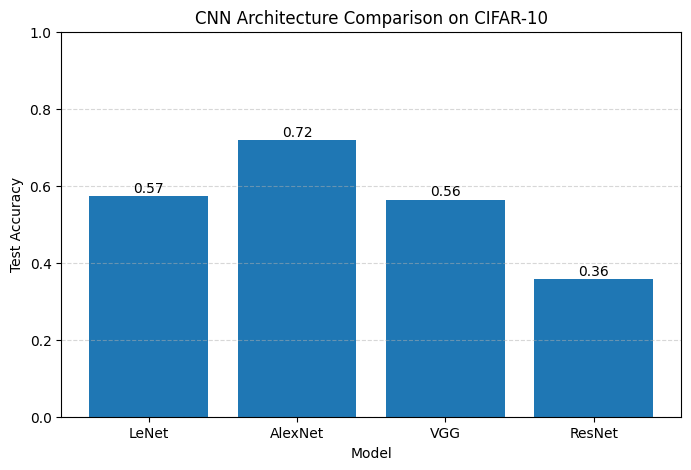

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
models = list(results.keys())
accuracies = list(results.values())

plt.bar(models, accuracies)
plt.title("CNN Architecture Comparison on CIFAR-10")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(accuracies):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center')

plt.show()

In [39]:
def plot_history(history, title="Training Curves"):
    plt.figure(figsize=(12,4))
    
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.show()

    history, acc = train_model(...)
    plot_history(history, "ResNet")

to note it down: Deeper architectures like VGG and ResNet performed better because they extract more complex hierarchical features compared to shallow networks like LeNet.

# PART-2 (Loss Function Comparison)

## BCE

loss_bce = tf.keras.losses.BinaryCrossentropy()

In [12]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(weight * ce)
    return loss

loss_focal = focal_loss()

Focal Loss (manual)

In [ ]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(weight * ce)
    return loss

loss_focal = focal_loss()

VGG + BCE

In [ ]:
model_alex = AlexNet(input_shape)
_, acc_alex_focal = train_model(
    model_alex,
    x_train, y_train,
    x_test, y_test,
    loss=loss_focal,
    optimizer="sgd",
    epochs=3
)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.1155 - loss: 0.0464 - val_accuracy: 0.1216 - val_loss: 0.0462
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.1285 - loss: 0.0461 - val_accuracy: 0.1476 - val_loss: 0.0459
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.1553 - loss: 0.0457 - val_accuracy: 0.1694 - val_loss: 0.0455


In [26]:
model_alex = AlexNet(input_shape)
_, acc_alex_focal = train_model(
    model_alex,
    x_train, y_train,
    x_test, y_test,
    loss=loss_focal,
    optimizer="sgd",
    epochs=4
)

/Users/harshilandhariya/Desktop/SEM 6/DL/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.1328 - loss: 0.0465 - val_accuracy: 0.1228 - val_loss: 0.0463
Epoch 2/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.1305 - loss: 0.0462 - val_accuracy: 0.1428 - val_loss: 0.0460
Epoch 3/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.1508 - loss: 0.0459 - val_accuracy: 0.1618 - val_loss: 0.0457
Epoch 4/4
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.1710 - loss: 0.0456 - val_accuracy: 0.1776 - val_loss: 0.0454


In [19]:
class ArcFaceLayer(tf.keras.layers.Layer):
    def __init__(self, num_classes, scale=30.0):
        super().__init__()
        self.num_classes = num_classes
        self.scale = scale

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], self.num_classes),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, inputs):
        x = tf.nn.l2_normalize(inputs, axis=1)
        W = tf.nn.l2_normalize(self.W, axis=0)
        return tf.matmul(x, W) * self.scale

In [21]:
base = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(32,32,3)
)
base.trainable = False

x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(128)(x)
output = ArcFaceLayer(10)(x)

model_resnet_arc = tf.keras.Model(base.input, output)

model_resnet_arc.compile(
    optimizer="adam",
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model_resnet_arc.fit(x_train, y_train, epochs=3, batch_size=64)
_, acc_resnet_arc = model_resnet_arc.evaluate(x_test, y_test)

Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 46ms/step - accuracy: 0.2396 - loss: 2.1170
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.3113 - loss: 1.9081
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.3362 - loss: 1.8448
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.3380 - loss: 1.8385


In [23]:
print("\nPart-2 Results")
# print("VGG + Adam + BCE:", acc_vgg_bce)
print("AlexNet + SGD + Focal:", acc_alex_focal)
print("ResNet + Adam + ArcFace:", acc_resnet_arc)


Part-2 Results
AlexNet + SGD + Focal: 0.1500999927520752
ResNet + Adam + ArcFace: 0.33799999952316284


BCE works well for balanced data.
Focal loss focuses on hard examples.
ArcFace improves feature separability by enforcing angular margin, leading to better clustering.

# PART-3 (t-SNE Visualization)

## Feature Extraction

In [24]:
feature_model = tf.keras.Model(
    inputs=model_resnet_arc.input,
    outputs=model_resnet_arc.layers[-2].output
)

features = feature_model.predict(x_test[:2000])
labels = np.argmax(y_test[:2000], axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


## t-SNE Plot

t-SNE shows that ArcFace produces more compact and well-separated class clusters compared to standard loss.

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


/Users/harshilandhariya/Desktop/SEM 6/DL/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/harshilandhariya/Desktop/SEM 6/DL/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/harshilandhariya/Desktop/SEM 6/DL/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/harshilandhariya/Desktop/SEM 6/DL/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/harshilandhariya/Desktop/SEM 6/DL/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/harshilandhariya/Desktop/SEM 6/DL/.venv/lib/python3.10/site-packages/skl

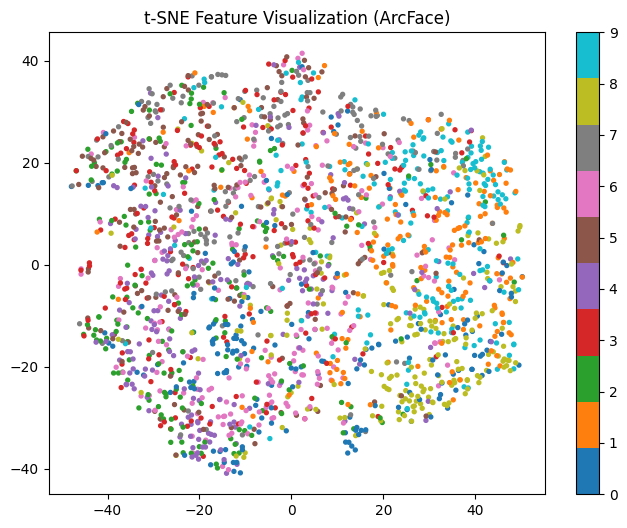

In [34]:
from sklearn.manifold import TSNE

feature_model = tf.keras.Model(
    inputs=model_resnet_arc.input,
    outputs=model_resnet_arc.layers[-2].output
)

features = feature_model.predict(x_test[:2000])
labels = np.argmax(y_test[:2000], axis=1)

tsne = TSNE(n_components=2, random_state=42)
embeddings = tsne.fit_transform(features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    embeddings[:,0],
    embeddings[:,1],
    c=labels,
    cmap='tab10',
    s=8
)
plt.title("t-SNE Feature Visualization (ArcFace)")
plt.colorbar(scatter)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


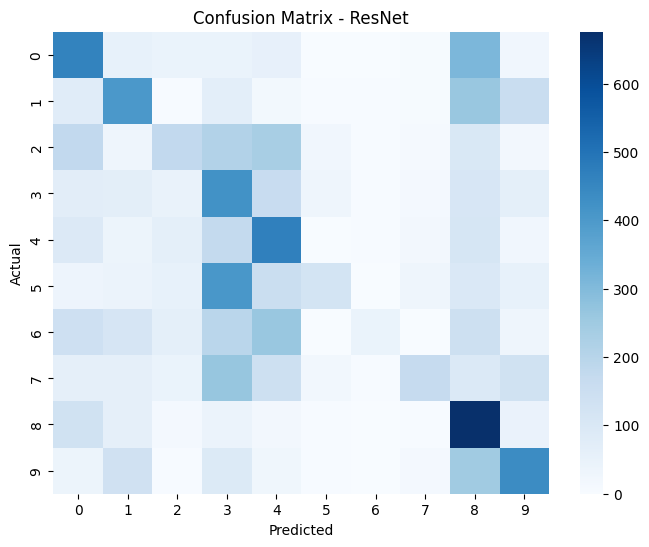

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model_resnet_arc.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues", fmt='d')
plt.title("Confusion Matrix - ResNet")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


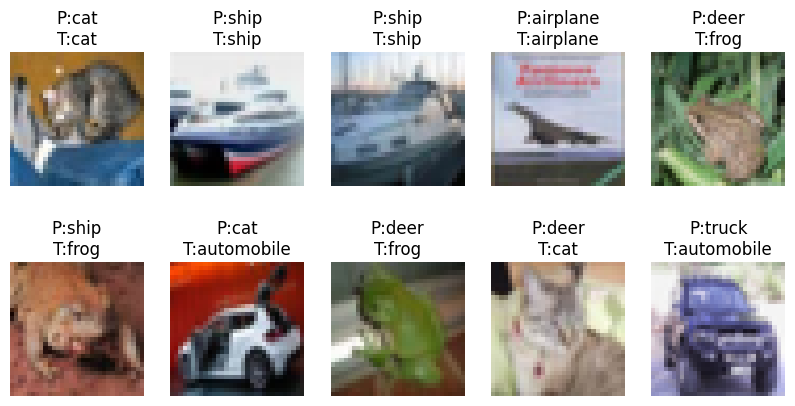

In [36]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    pred = np.argmax(model_resnet_arc.predict(x_test[i:i+1]))
    true = np.argmax(y_test[i])
    plt.title(f"P:{class_names[pred]}\nT:{class_names[true]}")
    plt.axis('off')

plt.show()